# Train Split EDA

Minimal exploratory data analysis for the Kaggle Speech Recognition Challenge train split.

This notebook uses `speech_recognition.SpeechCommandsDataset` to:
- load/train split
- inspect class distribution
- inspect audio duration distribution
- inspect sample rate distribution
- inspect stats for the report

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import wave
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from speech_recognition import SpeechCommandsDataset

sns.set_theme(style="whitegrid")
sns.set_palette("Set2")

## Load dataset manager and train split

In [3]:
dataset = SpeechCommandsDataset(auto_download=True, only_1sec_samples=False)
train_samples = dataset.train

print("Dataset root:", dataset.dataset_root)
print("Stats:", dataset.stats())
print("Train samples:", len(train_samples))

2026-04-01 23:50:04,693 - speech_recognition.dataset - INFO - Building splits using official lists (validation=6798, testing=6835)
2026-04-01 23:50:07,911 - speech_recognition.dataset - INFO - Built splits with counts: train=51094, val=6798, test=158538
2026-04-01 23:50:07,916 - speech_recognition.dataset - INFO - Dataset initialized with split sizes: {'train': 51094, 'val': 6798, 'test': 158538}


Dataset root: /Users/pawelp/Desktop/education/pw/deepl/speech-recognition/data/kaggle_speech_commands/tensorflow-speech-recognition-challenge
Stats: {'train': 51094, 'val': 6798, 'test': 158538}
Train samples: 51094


## Build train metadata table

In [4]:
def read_wav_meta(path: Path) -> tuple[int, int, float, int]:
    """Return (sample_rate, n_frames, duration_sec, sample_width_bytes)."""
    with wave.open(str(path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        sample_width = wav_file.getsampwidth()
    duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0
    return sample_rate, n_frames, duration_sec, sample_width


rows: list[dict[str, object]] = []
for sample in tqdm(train_samples, desc="Reading train metadata"):
    sample_rate, n_frames, duration_sec, sample_width = read_wav_meta(sample.path)
    rows.append(
        {
            "path": str(sample.path),
            "filename": sample.filename,
            "label": sample.label,
            "sample_rate": sample_rate,
            "n_frames": n_frames,
            "duration_sec": duration_sec,
            "sample_width_bytes": sample_width,
        }
    )

train_df = pd.DataFrame(rows)
train_df.head()

Reading train metadata:   0%|          | 0/51094 [00:00<?, ?it/s]

,path,filename,label,sample_rate,n_frames,duration_sec,sample_width_bytes
0,/Users/pawelp/Desktop/education/pw/deepl/speec...,doing_the_dishes.wav,_background_noise_,16000,1522930,95.183125,2
1,/Users/pawelp/Desktop/education/pw/deepl/speec...,dude_miaowing.wav,_background_noise_,16000,988891,61.805687,2
2,/Users/pawelp/Desktop/education/pw/deepl/speec...,exercise_bike.wav,_background_noise_,16000,980062,61.253875,2
3,/Users/pawelp/Desktop/education/pw/deepl/speec...,pink_noise.wav,_background_noise_,16000,960000,60.000000,2
4,/Users/pawelp/Desktop/education/pw/deepl/speec...,running_tap.wav,_background_noise_,16000,978488,61.155500,2


## Basic summary

In [5]:
train_df.describe(include="all").transpose().head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path,51094,51094,/Users/pawelp/Desktop/education/pw/deepl/speec...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filename,51094,5110,0132a06d_nohash_0.wav,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,51094,31,one,1892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_rate,51094.0,NaN,NaN,NaN,16000.0,0.0,16000.0,16000.0,16000.0,16000.0,16000.0
n_frames,51094.0,NaN,NaN,NaN,15869.482718,11625.319238,5945.0,16000.0,16000.0,16000.0,1522930.0
duration_sec,51094.0,NaN,NaN,NaN,0.991843,0.726582,0.371563,1.0,1.0,1.0,95.183125
sample_width_bytes,51094.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0


In [6]:
print("Unique labels:", train_df["label"].nunique())
print("Unique sample rates:", sorted(train_df["sample_rate"].dropna().unique().tolist()))
print("Duration range (sec):", train_df["duration_sec"].min(), "->", train_df["duration_sec"].max())

Unique labels: 31
Unique sample rates: [16000]
Duration range (sec): 0.3715625 -> 95.183125


## Class distribution (train)

In [7]:
label_counts = train_df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.head()

,label,count
0,one,1892
1,stop,1885
2,nine,1875
3,seven,1875
4,two,1873


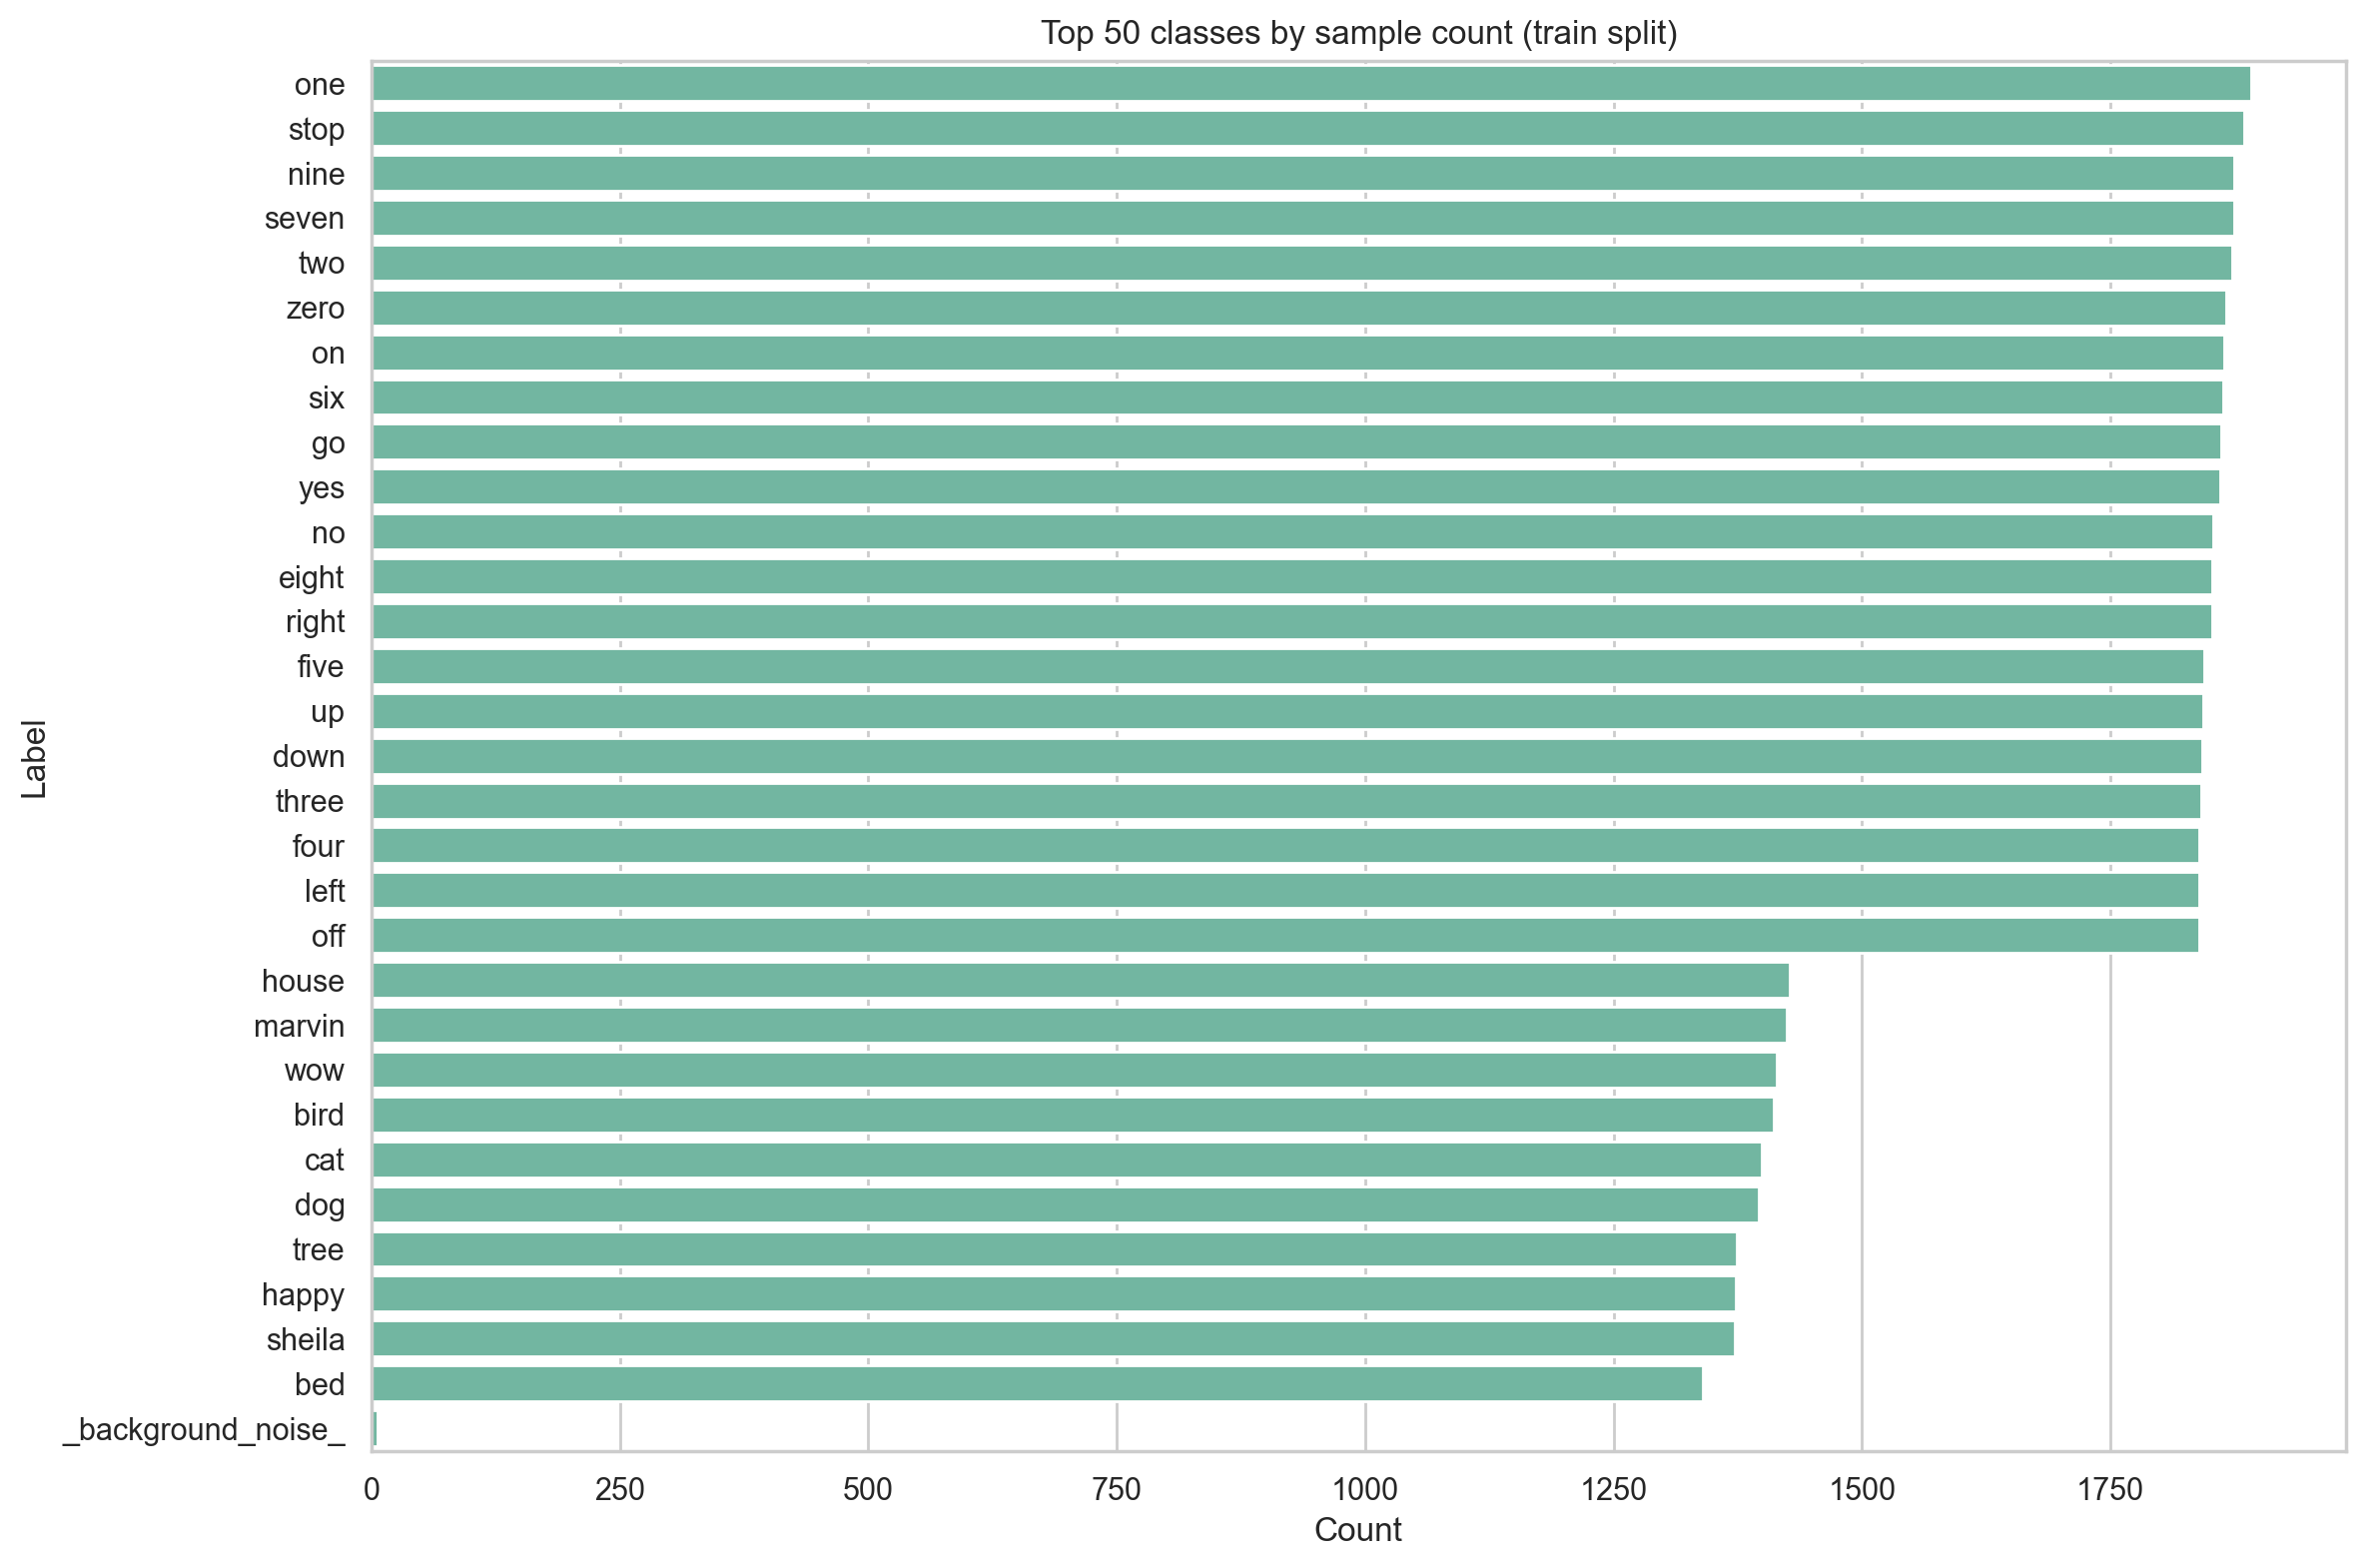

In [8]:
top_n = 50
plot_df = label_counts.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df, y="label", x="count", legend=False)
plt.title(f"Top {top_n} classes by sample count (train split)")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

## Duration analysis

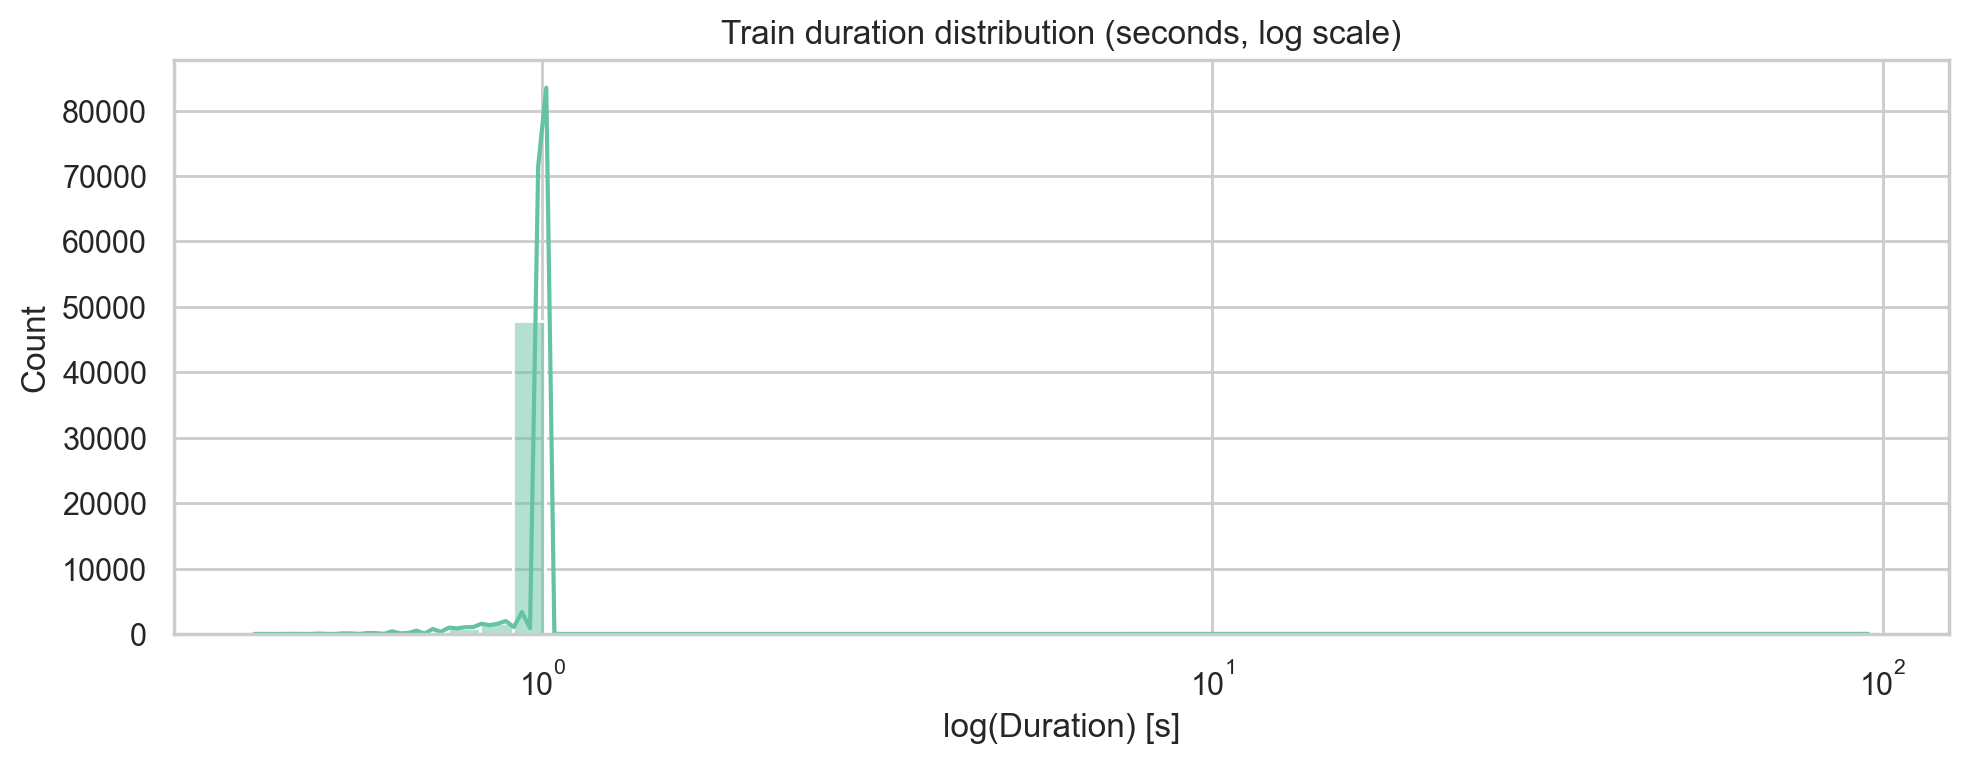

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df["duration_sec"], bins=50, kde=True, log_scale=True)
plt.title("Train duration distribution (seconds, log scale)")
plt.xlabel("log(Duration) [s]")
plt.tight_layout()
plt.show()

In [10]:
duration_by_label = (
    train_df.groupby("label", as_index=False)["duration_sec"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)
duration_by_label.head(10)

,index,label,count,mean,std,min,max
0,0,_background_noise_,6,66.566365,14.037929,60.000000,95.183125
1,1,bed,1340,0.980708,0.061532,0.469375,1.000000
2,2,bird,1411,0.980601,0.067142,0.490687,1.000000
3,3,cat,1399,0.980658,0.063761,0.510875,1.000000
4,4,dog,1396,0.982350,0.062556,0.464438,1.000000
5,5,down,1842,0.986294,0.053785,0.512000,1.000000
6,6,eight,1852,0.983656,0.060662,0.418000,1.000000
7,7,five,1844,0.987327,0.054505,0.510875,1.000000
8,8,four,1839,0.984582,0.061428,0.512000,1.000000
9,9,go,1861,0.979583,0.071852,0.458688,1.000000


## Sample rate and sample width analysis

In [11]:
sr_counts = train_df["sample_rate"].value_counts().sort_index()
sw_counts = train_df["sample_width_bytes"].value_counts().sort_index()

print("Sample rate counts:")
display(sr_counts)

print("Sample width counts (bytes):")
display(sw_counts)

Sample rate counts:


sample_rate
16000    51094
Name: count, dtype: int64

Sample width counts (bytes):


sample_width_bytes
2    51094
Name: count, dtype: int64

In [12]:
rng = np.random.default_rng(42)
n_examples = 6
example_indices = rng.choice(len(train_df), size=min(n_examples, len(train_df)), replace=False)
examples = train_df.iloc[example_indices].reset_index(drop=True)
examples[["label", "filename", "duration_sec", "sample_rate"]]

,label,filename,duration_sec,sample_rate
0,seven,c1d39ce8_nohash_3.wav,1.00000,16000
1,three,44dad20e_nohash_0.wav,1.00000,16000
2,nine,b3849d6e_nohash_0.wav,1.00000,16000
3,two,de08912f_nohash_0.wav,1.00000,16000
4,nine,d4082f3e_nohash_0.wav,0.97525,16000
5,dog,462e1919_nohash_0.wav,1.00000,16000


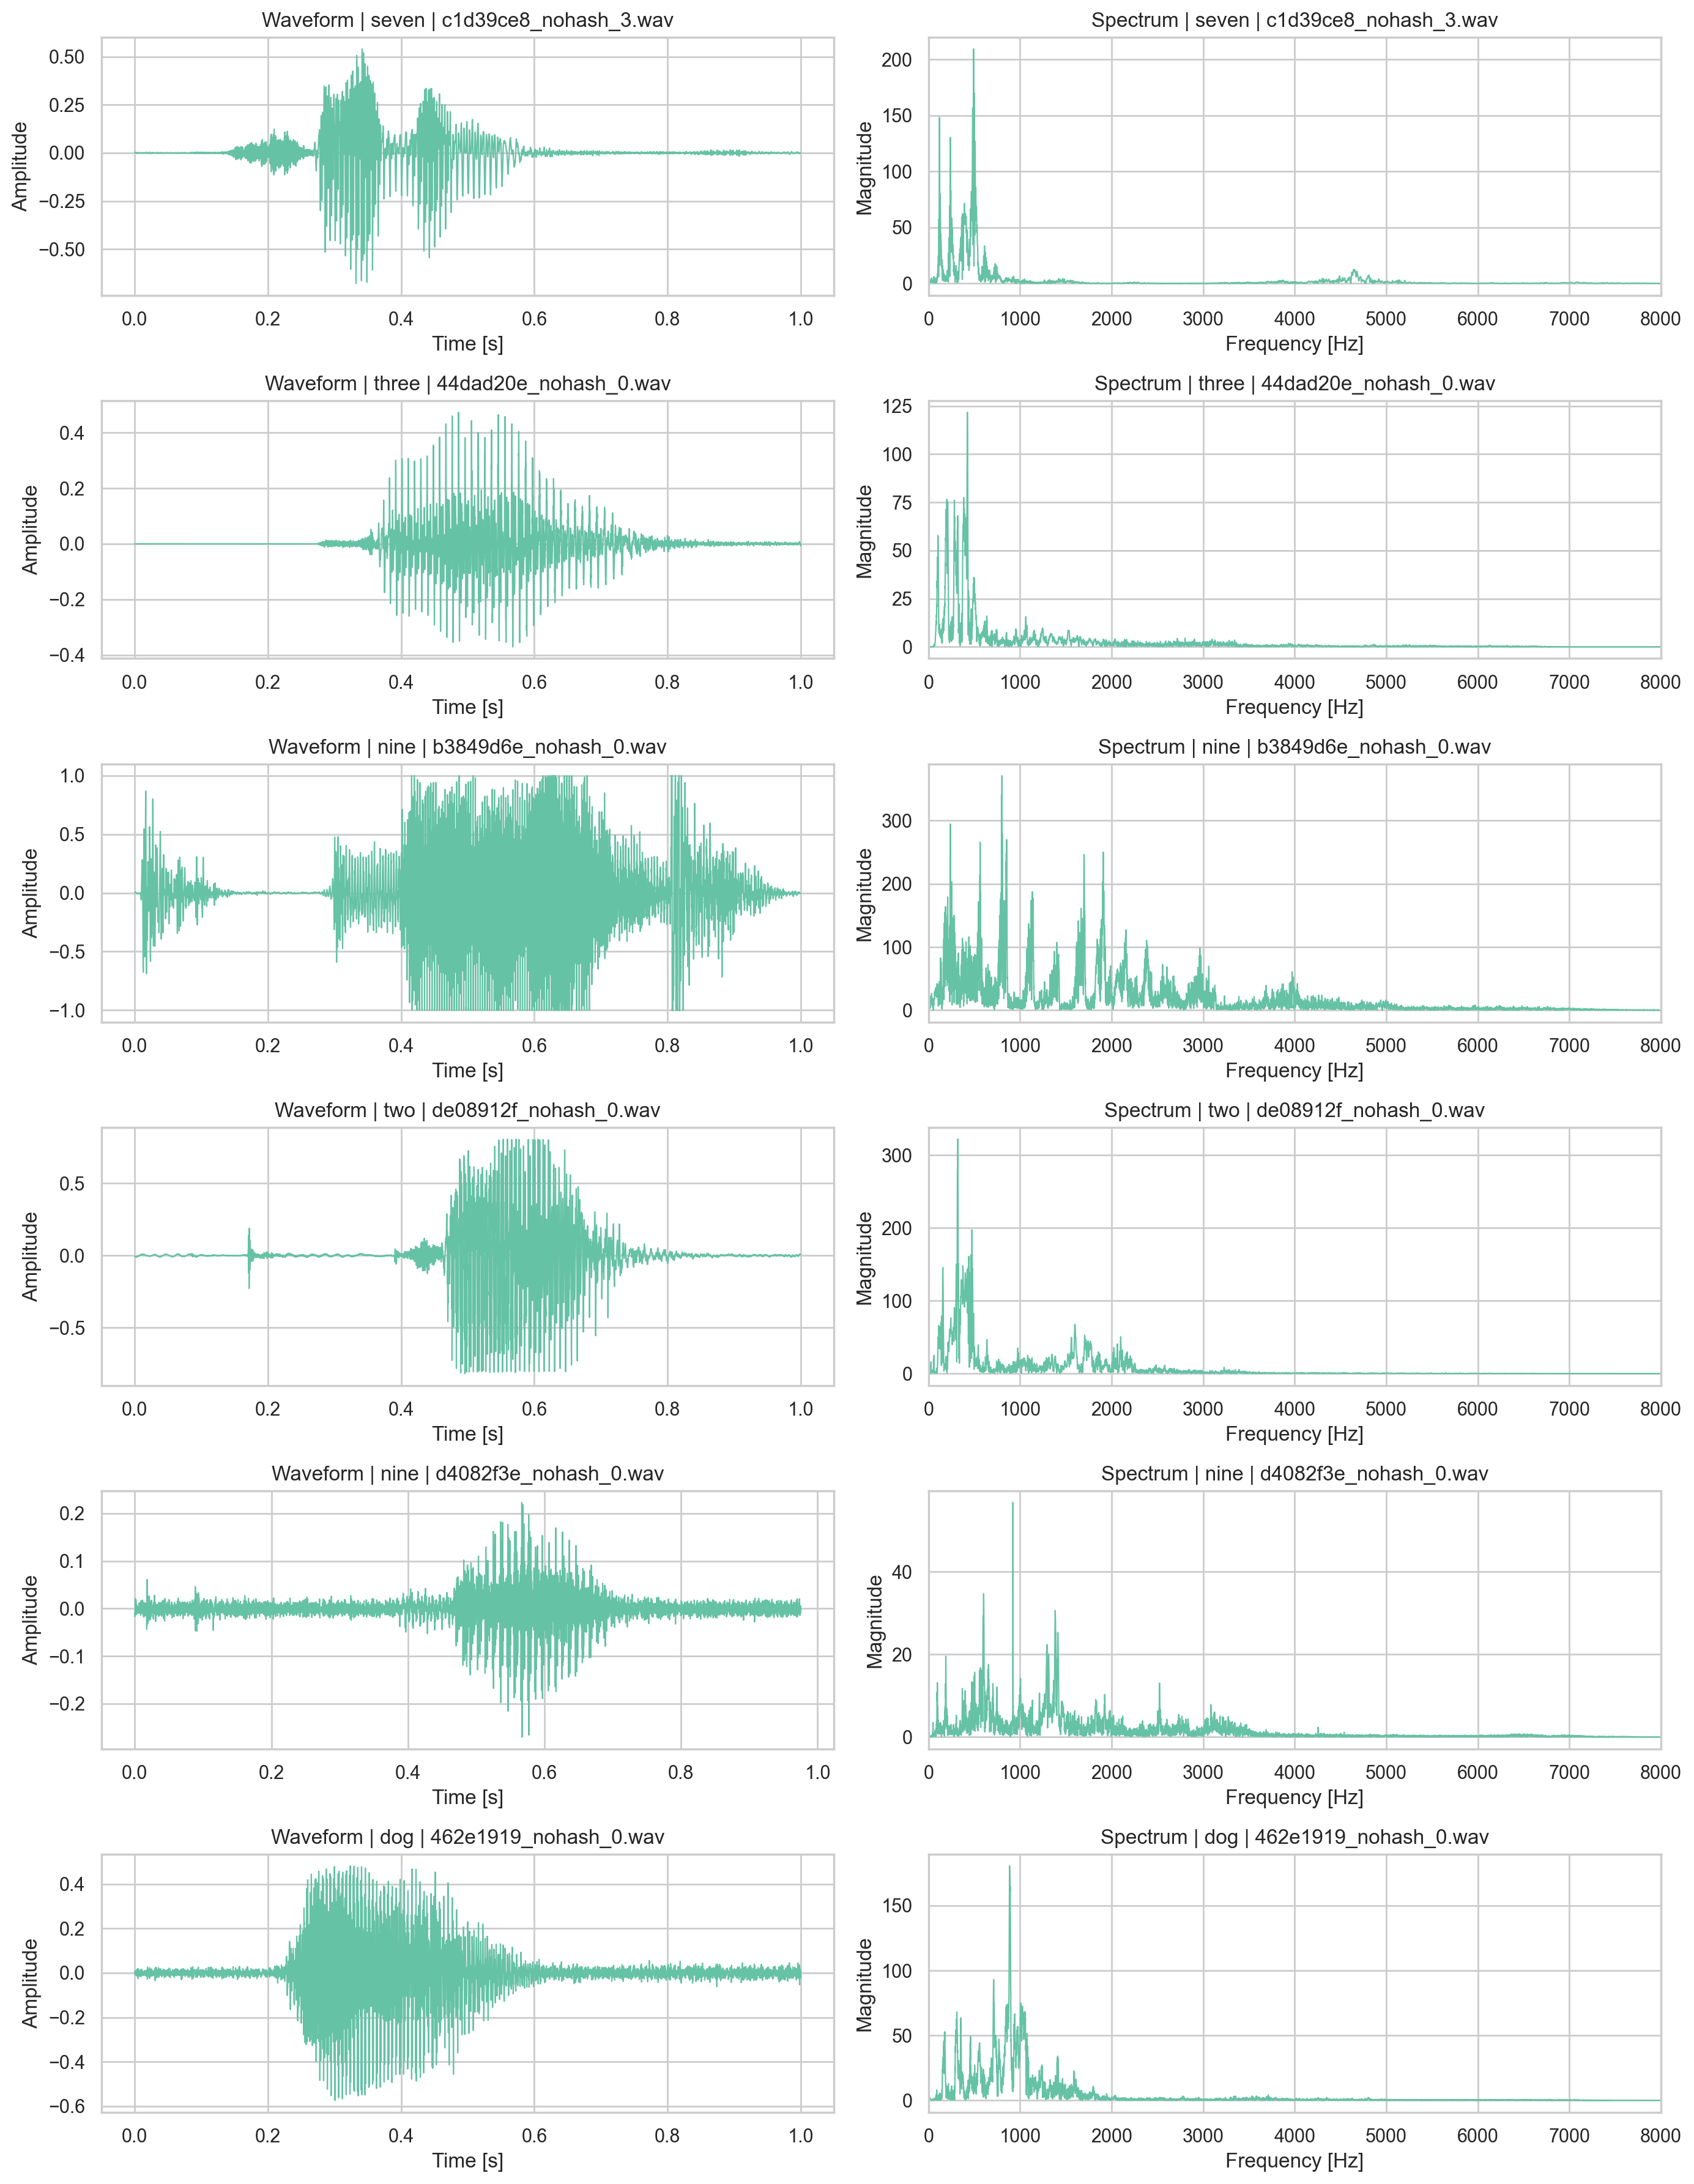

In [13]:
def read_pcm16_mono(path: Path) -> tuple[np.ndarray, int]:
    """Read wav file as float waveform and return (signal, sample_rate)."""
    with wave.open(str(path), "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        n_channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        frames = wav_file.readframes(wav_file.getnframes())

    if sample_width != 2:
        raise ValueError(
            f"Expected 16-bit PCM wav, got sample_width={sample_width} bytes for {path}"
        )

    signal = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32768.0
    if n_channels > 1:
        signal = signal.reshape(-1, n_channels).mean(axis=1)

    return signal, sample_rate


fig, axes = plt.subplots(nrows=len(examples), ncols=2, figsize=(14, 3 * len(examples)))
if len(examples) == 1:
    axes = np.array([axes])

for i, row in examples.iterrows():
    signal, sr = read_pcm16_mono(Path(row["path"]))
    t = np.arange(signal.shape[0]) / sr

    # Waveform
    ax_w = axes[i, 0]
    ax_w.plot(t, signal, linewidth=0.8)
    ax_w.set_title(f"Waveform | {row['label']} | {row['filename']}")
    ax_w.set_xlabel("Time [s]")
    ax_w.set_ylabel("Amplitude")

    # Magnitude spectrum
    ax_s = axes[i, 1]
    fft_vals = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(signal.shape[0], d=1.0 / sr)
    magnitude = np.abs(fft_vals)
    ax_s.plot(fft_freqs, magnitude, linewidth=0.8)
    ax_s.set_title(f"Spectrum | {row['label']} | {row['filename']}")
    ax_s.set_xlabel("Frequency [Hz]")
    ax_s.set_ylabel("Magnitude")
    ax_s.set_xlim(0, min(8000, sr // 2))

plt.tight_layout()
plt.show()

# Stats for report

In [14]:
# Build val and test metadata tables
def analyze_split(samples, split_name):
    """Analyze a split (val or test) and return statistics."""
    rows: list[dict[str, object]] = []
    for sample in tqdm(samples, desc=f"Reading {split_name} metadata"):
        sample_rate, n_frames, duration_sec, sample_width = read_wav_meta(sample.path)
        rows.append(
            {
                "path": str(sample.path),
                "filename": sample.filename,
                "label": sample.label,
                "sample_rate": sample_rate,
                "n_frames": n_frames,
                "duration_sec": duration_sec,
                "sample_width_bytes": sample_width,
            }
        )
    return pd.DataFrame(rows)


val_samples = dataset.val
test_samples = dataset.test

val_df = analyze_split(val_samples, "val")
test_df = analyze_split(test_samples, "test")

print(f"Validation split: {len(val_df)} samples")
print(f"Test split: {len(test_df)} samples")

Reading val metadata:   0%|          | 0/6798 [00:00<?, ?it/s]

Reading test metadata:   0%|          | 0/158538 [00:00<?, ?it/s]

Validation split: 6798 samples
Test split: 158538 samples


In [ ]:
# Comprehensive stats for all splits
print("=" * 100)
print("COMPREHENSIVE DATASET STATISTICS FOR ALL SPLITS (FOR REPORT)")
print("=" * 100)

splits_data = {
    "train": (train_df, len(train_df)),
    "val": (val_df, len(val_df)),
    "test": (test_df, len(test_df)),
}

for split_name, (df, total_count) in splits_data.items():
    print(f"\n{split_name.upper()} SPLIT")
    print("-" * 100)
    print(f"Total samples: {total_count:,}")
    print(f"Unique classes: {df['label'].nunique()}")
    print(f"Unique sample rates: {sorted(df['sample_rate'].dropna().unique().tolist())}")
    print("\nDuration statistics (seconds):")
    print(f"  Min:    {df['duration_sec'].min():.4f}")
    print(f"  Max:    {df['duration_sec'].max():.4f}")
    print(f"  Mean:   {df['duration_sec'].mean():.4f}")
    print(f"  Median: {df['duration_sec'].median():.4f}")
    print(f"  Std:    {df['duration_sec'].std():.4f}")
    print(
        f"  1.0s:   {(df['duration_sec'] == 1.0).sum()} samples "
        f"({(df['duration_sec'] == 1.0).sum() / total_count * 100:.1f}%)"
    )

    # Frame statistics
    print("\nFrame statistics (at 16 kHz):")
    print(f"  Min frames:    {df['n_frames'].min():,}")
    print(f"  Max frames:    {df['n_frames'].max():,}")
    print(f"  Mean frames:   {df['n_frames'].mean():.0f}")
    print(
        f"  16000 frames:  {(df['n_frames'] == 16000).sum()} samples "
        f"({(df['n_frames'] == 16000).sum() / total_count * 100:.1f}%)"
    )

    # Class distribution for split
    top_classes = df["label"].value_counts().head(5)
    print("\nTop 5 classes:")
    for label, count in top_classes.items():
        pct = count / total_count * 100
        print(f"  {label:20s}: {count:5d} ({pct:5.2f}%)")

print("\n" + "=" * 100)

COMPREHENSIVE DATASET STATISTICS FOR ALL SPLITS (FOR REPORT)

TRAIN SPLIT
----------------------------------------------------------------------------------------------------
Total samples: 51,094
Unique classes: 31
Unique sample rates: [16000]

Duration statistics (seconds):
  Min:    0.3716
  Max:    95.1831
  Mean:   0.9918
  Median: 1.0000
  Std:    0.7266
  1.0s:   45884 samples (89.8%)

Frame statistics (at 16 kHz):
  Min frames:    5,945
  Max frames:    1,522,930
  Mean frames:   15869
  16000 frames:  45884 samples (89.8%)

Top 5 classes:
  one                 :  1892 ( 3.70%)
  stop                :  1885 ( 3.69%)
  nine                :  1875 ( 3.67%)
  seven               :  1875 ( 3.67%)
  two                 :  1873 ( 3.67%)

VAL SPLIT
----------------------------------------------------------------------------------------------------
Total samples: 6,798
Unique classes: 30
Unique sample rates: [16000]

Duration statistics (seconds):
  Min:    0.3840
  Max:    1.0000
  Me

In [16]:
# All class distribution with LaTeX table format
print("\n" + "=" * 80)
print("ALL CLASSES WITH COUNTS (LaTeX-formatted for report)")
print("=" * 80)

all_classes = label_counts.head(31)  # Get all 31 classes
print(f"\nTotal: {all_classes['count'].sum()} samples across {len(all_classes)} classes")

# Create LaTeX table format for all classes
print("\nAll classes:")
for idx, (_, row) in enumerate(all_classes.iterrows(), 1):
    pct = row["count"] / len(train_df) * 100
    print(f"{idx:2d}. {row['label']:20s} & {row['count']:5d} ({pct:5.2f}\\%)")

# Validation and test class distributions
print("=" * 100)
print("VALIDATION AND TEST SPLIT CLASS DISTRIBUTIONS")
print("=" * 100)

# Validation classes
print("\nVALIDATION SPLIT - All 30 classes:")
val_labels = val_df["label"].value_counts().reset_index(name="count")
val_labels.columns = ["label", "count"]
val_labels["pct"] = (val_labels["count"] / len(val_df) * 100).round(2)

for idx, (_, row) in enumerate(val_labels.iterrows(), 1):
    print(f"{idx:2d}. {row['label']:20s} & {row['count']:5d} & {row['pct']:5.2f}\\\\")

# Test classes
print("\nTEST SPLIT - Class composition:")
test_labels = test_df["label"].value_counts().reset_index(name="count")
test_labels.columns = ["label", "count"]
test_labels["pct"] = (test_labels["count"] / len(test_df) * 100).round(2)

for idx, (_, row) in enumerate(test_labels.iterrows(), 1):
    print(f"{idx}. {row['label']:20s}: {row['count']:,} samples ({row['pct']:5.2f}%)")

print("\nNote: All 158,538 test samples are labeled '__unknown__' (blind evaluation)")


ALL CLASSES WITH COUNTS (LaTeX-formatted for report)

Total: 51094 samples across 31 classes

All classes:
 1. one                  &  1892 ( 3.70\%)
 2. stop                 &  1885 ( 3.69\%)
 3. nine                 &  1875 ( 3.67\%)
 4. seven                &  1875 ( 3.67\%)
 5. two                  &  1873 ( 3.67\%)
 6. zero                 &  1866 ( 3.65\%)
 7. on                   &  1864 ( 3.65\%)
 8. six                  &  1863 ( 3.65\%)
 9. go                   &  1861 ( 3.64\%)
10. yes                  &  1860 ( 3.64\%)
11. no                   &  1853 ( 3.63\%)
12. eight                &  1852 ( 3.62\%)
13. right                &  1852 ( 3.62\%)
14. five                 &  1844 ( 3.61\%)
15. up                   &  1843 ( 3.61\%)
16. down                 &  1842 ( 3.61\%)
17. three                &  1841 ( 3.60\%)
18. four                 &  1839 ( 3.60\%)
19. left                 &  1839 ( 3.60\%)
20. off                  &  1839 ( 3.60\%)
21. house                &  1427

# Final samples

In [17]:
len(SpeechCommandsDataset(auto_download=True, only_1sec_samples=True).train)

2026-04-01 23:50:31,779 - speech_recognition.dataset - INFO - Building splits using official lists (validation=6798, testing=6835)
2026-04-01 23:50:34,466 - speech_recognition.dataset - INFO - Filtering splits to keep only 1-second samples (only_1sec_samples=True)
2026-04-01 23:50:53,823 - speech_recognition.dataset - INFO - After 1-second filtering: train=51094->45884, val=6798->6137, test=158538->158538
2026-04-01 23:50:53,823 - speech_recognition.dataset - INFO - Built splits with counts: train=45884, val=6137, test=158538
2026-04-01 23:50:53,831 - speech_recognition.dataset - INFO - Dataset initialized with split sizes: {'train': 45884, 'val': 6137, 'test': 158538}


45884